In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA e bounds
- salvataggio fit

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_789/Mrk-789_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_789/Mrk-789_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     379   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        60   (2094, 964)   float32   


In [4]:
image_cut = image[75:175, 0:1890]
image_error_cut = image_error[75:175, 0:1890]

Text(0.5, 0, 'wavelength')

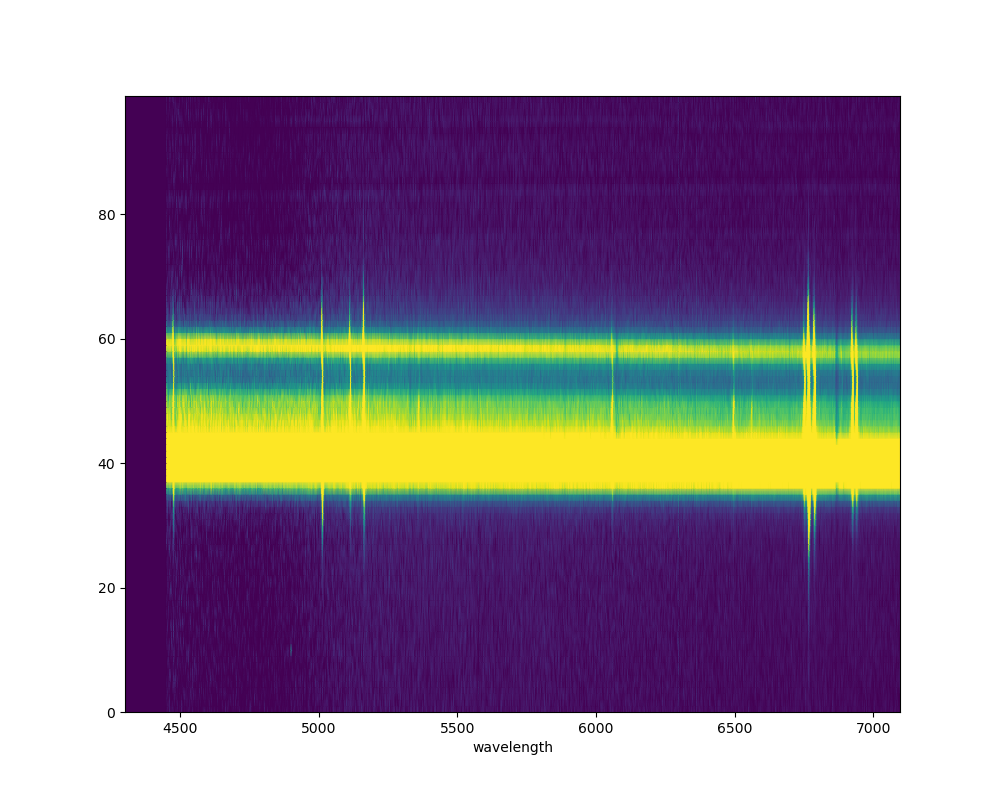

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [6]:
z = 0.03144
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)
seeing = 1.984
sigma = seeing / 2.35
n_component = 3

In [7]:
l_HA

6769.340719999999

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_789/Mrk-789_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     379   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        60   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

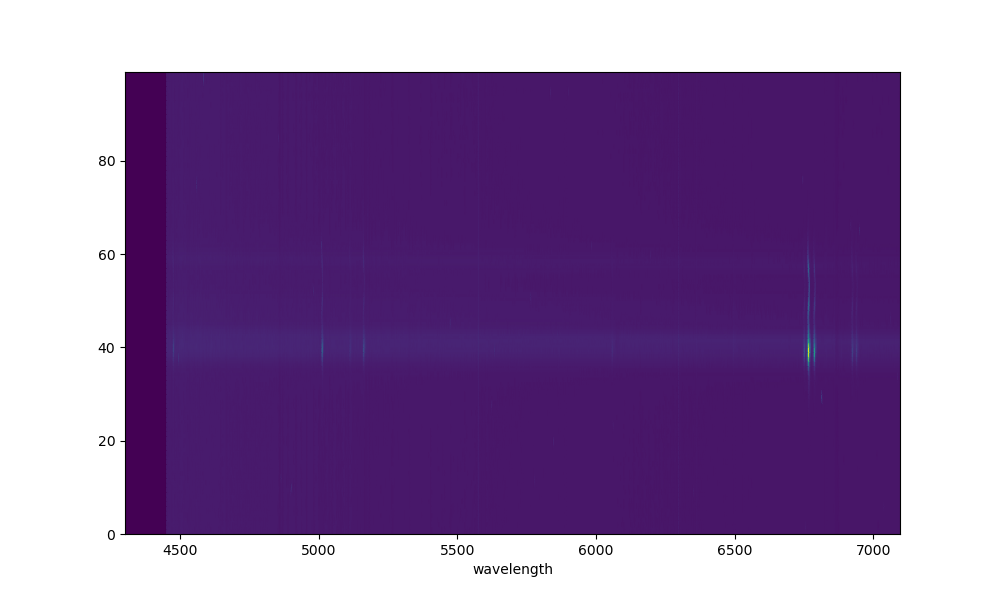

In [8]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_789/Mrk-789_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[75:175, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

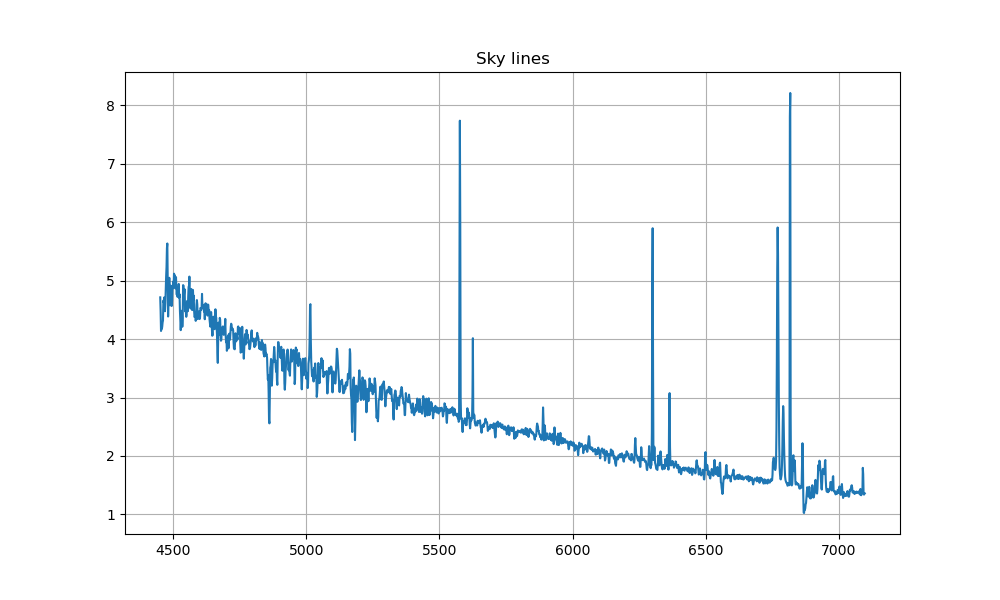

In [9]:
mask_sky = (y > 24)*(y < 34)
mask_wv = wv > 4451
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

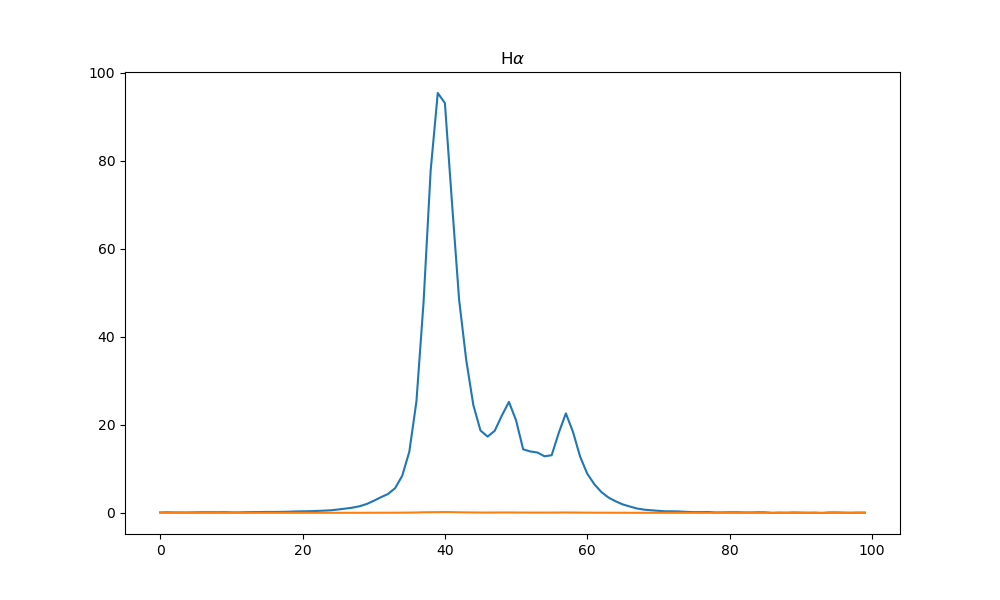

In [10]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [11]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) #+
        #sersic_1d(x_hr, *params[12:16]) +
        #sersic_1d(x_hr, *params[16:20])+ 
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 100)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 100)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (35, 45),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (45, 54),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (54, 65)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

In [12]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 7226.664569614486
differential_evolution step 2: f(x)= 5842.414992112539
differential_evolution step 3: f(x)= 5681.204309007735
differential_evolution step 4: f(x)= 5681.204309007735
differential_evolution step 5: f(x)= 5681.204309007735
differential_evolution step 6: f(x)= 3509.1888043568406
differential_evolution step 7: f(x)= 2102.9257223426584
differential_evolution step 8: f(x)= 2102.9257223426584
differential_evolution step 9: f(x)= 2102.9257223426584
differential_evolution step 10: f(x)= 2102.9257223426584
differential_evolution step 11: f(x)= 2102.9257223426584
differential_evolution step 12: f(x)= 2102.9257223426584
differential_evolution step 13: f(x)= 2102.9257223426584
differential_evolution step 14: f(x)= 2102.9257223426584
differential_evolution step 15: f(x)= 2030.8621766714568
differential_evolution step 16: f(x)= 2030.8621766714568
differential_evolution step 17: f(x)= 1970.9365225611289
differential_evolution step 18: f(x)= 1970.93

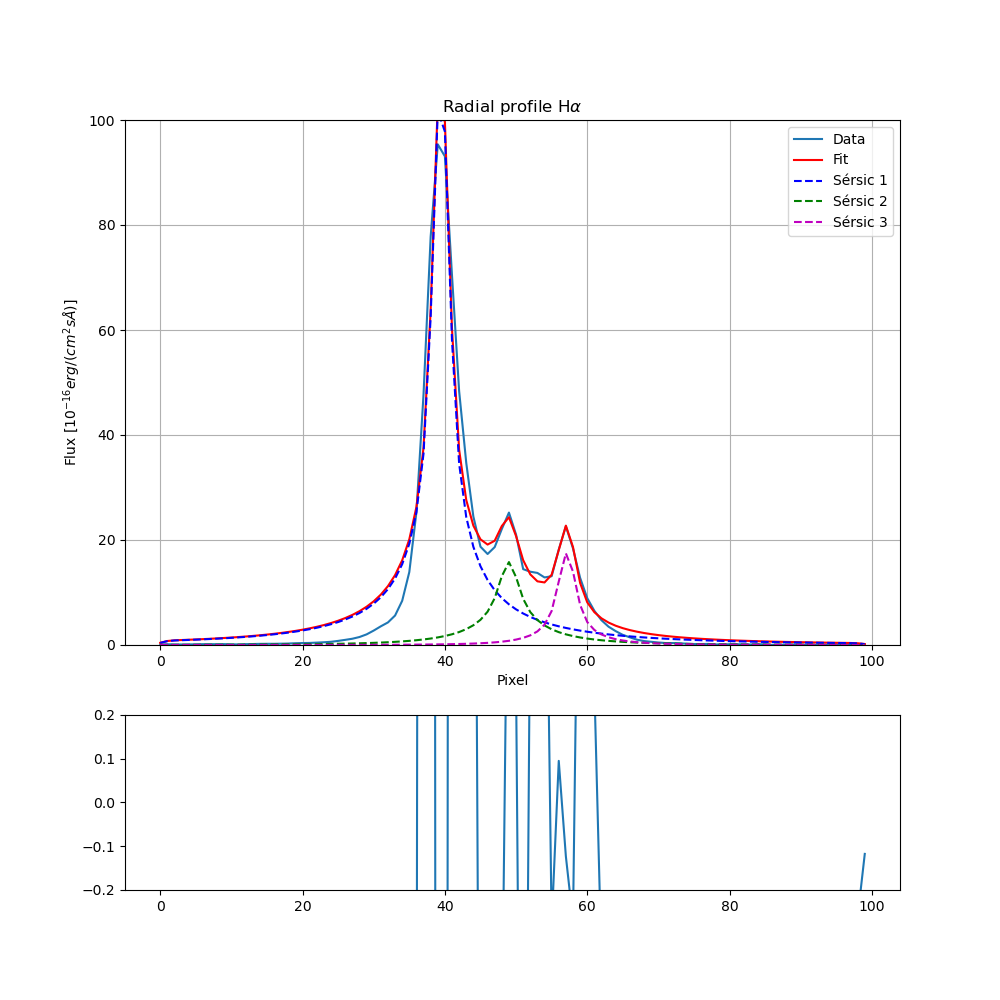

In [13]:
plot_diff(x_axes, best_params, radial_profile_HA, r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [14]:
params_curve_HA, covariance_HA = curve_fit(model_convolved, x_axes, radial_profile_HA, p0=result.x, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, radial_profile_error_HA,
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16936\3403565850.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16936\3403565850.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=13.7486, r_e=4.2058, n=1.3625, x_0=39.3217
Sérsic 2: I_e=12.5531, r_e=6.7350, n=0.1060, x_0=44.6136
Sérsic 3: I_e=3.5016, r_e=5.9281, n=1.2371, x_0=56.9392
[1.8554462  0.26711049 0.11077717 0.06618654 1.5433129  1.10031342
 0.0449558  0.33414364 0.68900671 0.67744074 0.15123885 0.12743521]
224.0262131852306


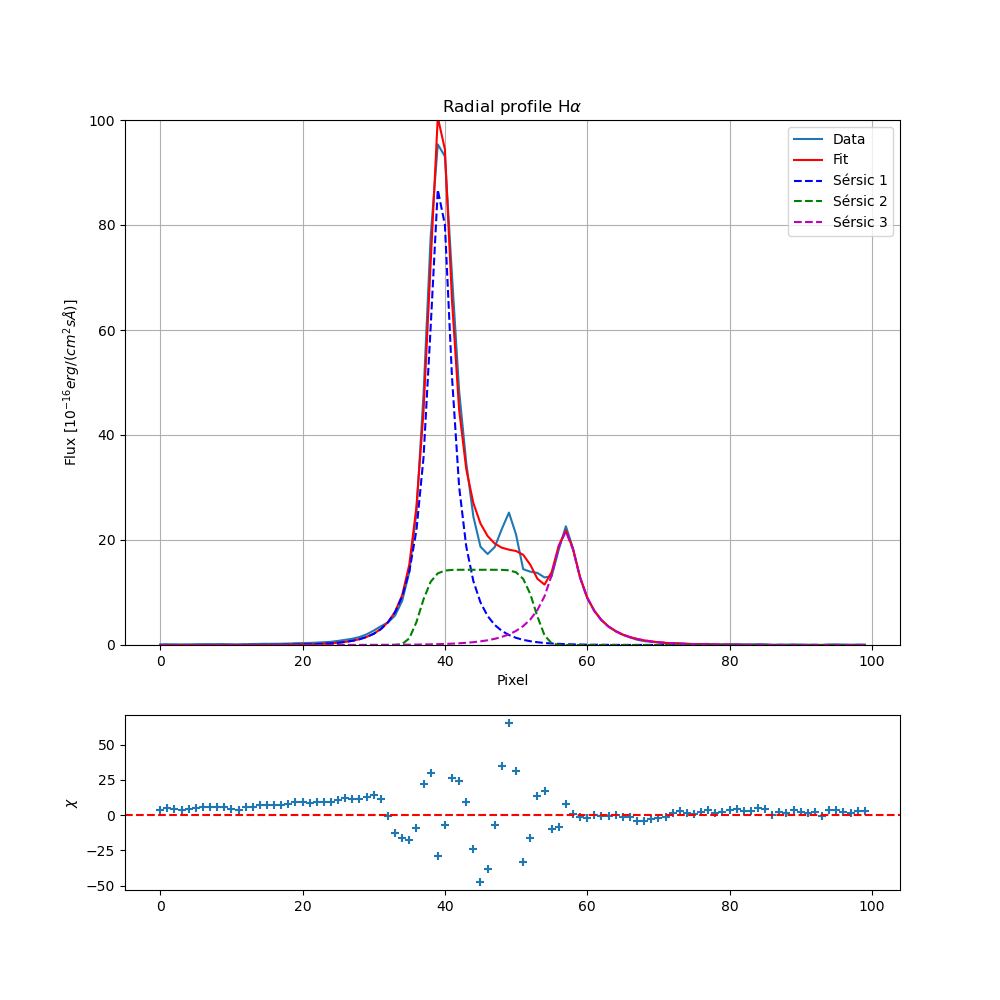

In [15]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [16]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-(seeing/2), x_0_HA[0]+(seeing/2)),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-(seeing/2), x_0_HA[1]+(seeing/2)),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-(seeing/2), x_0_HA[2]+(seeing/2)),

]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

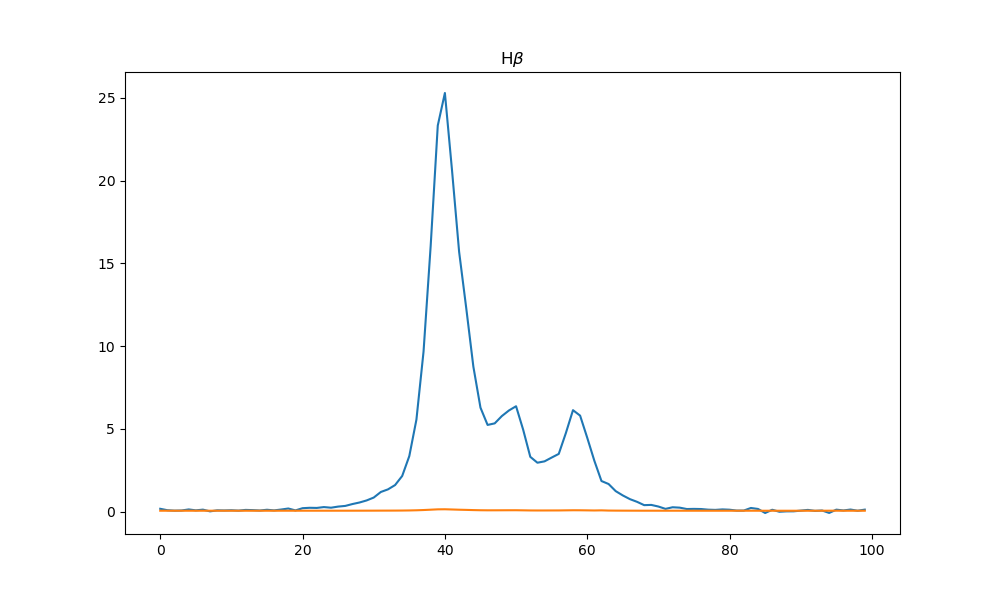

In [17]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [18]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 227.4627482632953
differential_evolution step 2: f(x)= 227.4627482632953
differential_evolution step 3: f(x)= 227.4627482632953
differential_evolution step 4: f(x)= 227.4627482632953
differential_evolution step 5: f(x)= 152.42245887312777
differential_evolution step 6: f(x)= 152.42245887312777
differential_evolution step 7: f(x)= 152.42245887312777
differential_evolution step 8: f(x)= 152.42245887312777
differential_evolution step 9: f(x)= 152.42245887312777
differential_evolution step 10: f(x)= 141.49338899326148
differential_evolution step 11: f(x)= 141.49338899326148
differential_evolution step 12: f(x)= 141.49338899326148
differential_evolution step 13: f(x)= 141.49338899326148
differential_evolution step 14: f(x)= 141.49338899326148
differential_evolution step 15: f(x)= 141.49338899326148
differential_evolution step 16: f(x)= 114.34564030115266
differential_evolution step 17: f(x)= 114.34564030115266
differential_evolution step 18: f(x)= 114.34

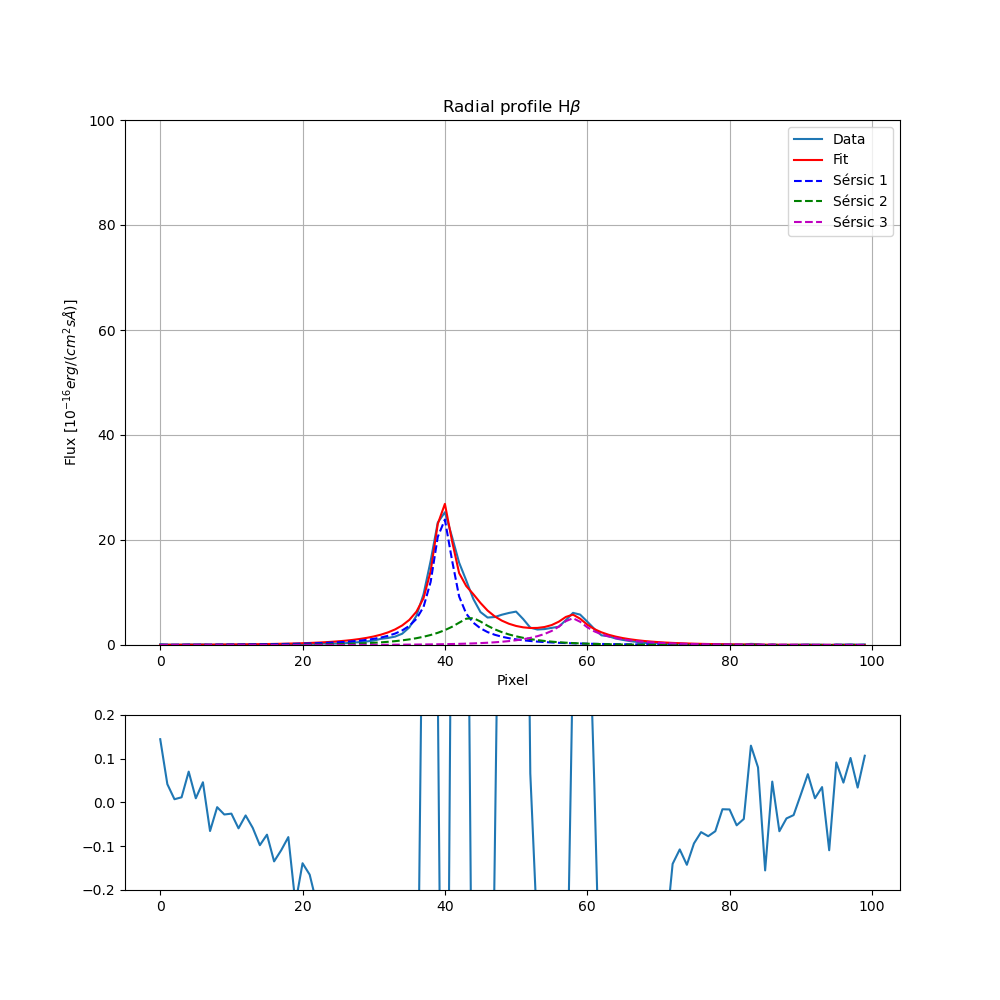

In [19]:
plot_diff(x_axes, best_params, radial_profile_HB, r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [20]:
params_curve_HB, covariance_HB = curve_fit(model_convolved, x_axes, radial_profile_HB, p0=result.x, sigma = radial_profile_error_HB)

chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, radial_profile_error_HB,
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16936\3403565850.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16936\3403565850.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16936\3403565850.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\anaconda3\Lib\site-packages\scipy\signal\_signaltools.py:511: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)


Sérsic 1: I_e=3.3818, r_e=4.7987, n=1.3308, x_0=39.8423
Sérsic 2: I_e=1.5986, r_e=7.6671, n=0.0441, x_0=44.5744
Sérsic 3: I_e=1.0185, r_e=6.8824, n=1.1772, x_0=58.1523
[0.44834977 0.35952136 0.10353458 0.05685355 3.80995661 0.82314649
 0.05232055 0.20140901 0.20570585 0.97225464 0.14283868 0.10843651]
21.19363925579504


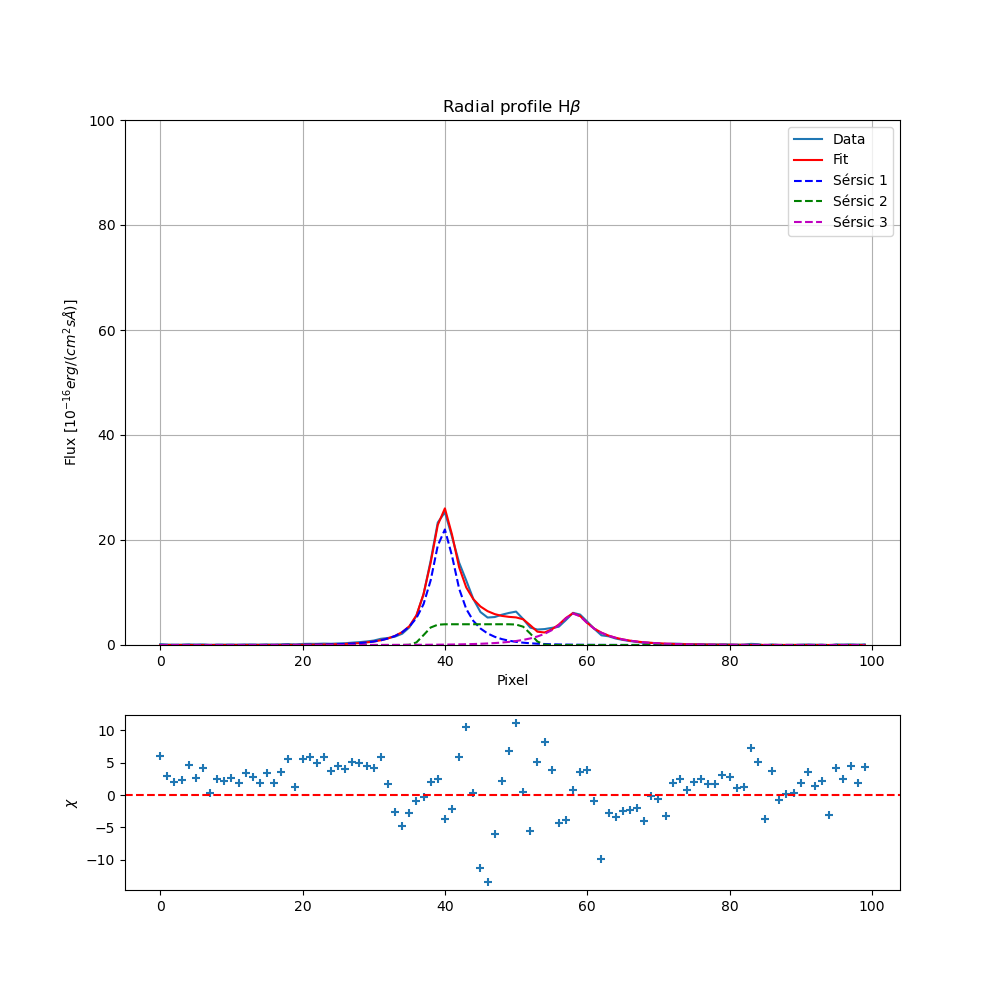

In [21]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

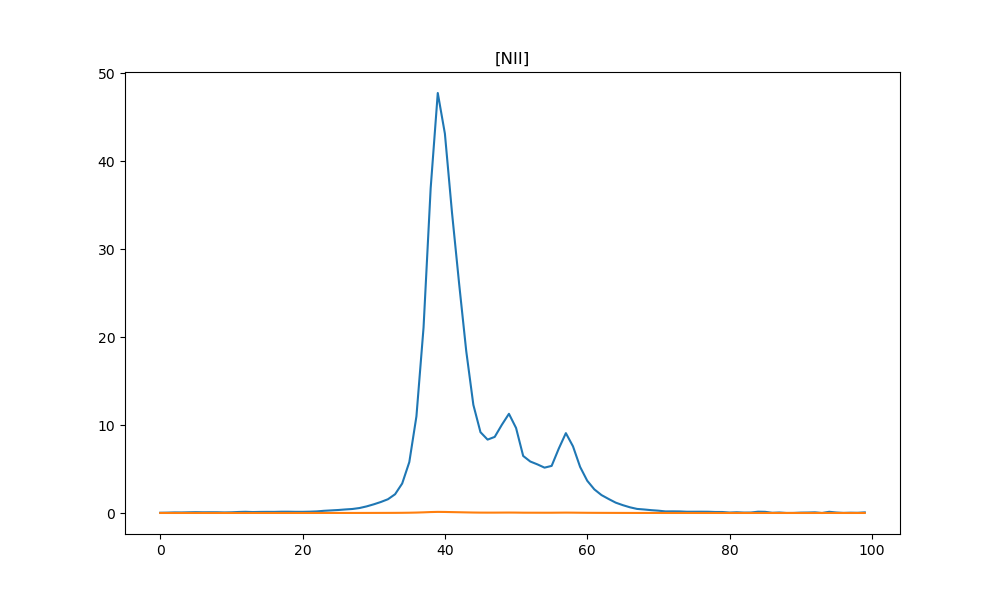

In [22]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [23]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 920.2300545336338
differential_evolution step 2: f(x)= 630.5108395912315
differential_evolution step 3: f(x)= 494.59207636288374
differential_evolution step 4: f(x)= 494.59207636288374
differential_evolution step 5: f(x)= 494.59207636288374
differential_evolution step 6: f(x)= 494.59207636288374
differential_evolution step 7: f(x)= 494.59207636288374
differential_evolution step 8: f(x)= 494.59207636288374
differential_evolution step 9: f(x)= 430.7192550181591
differential_evolution step 10: f(x)= 430.7192550181591
differential_evolution step 11: f(x)= 430.7192550181591
differential_evolution step 12: f(x)= 430.7192550181591
differential_evolution step 13: f(x)= 430.7192550181591
differential_evolution step 14: f(x)= 410.80526319000614
differential_evolution step 15: f(x)= 410.80526319000614
differential_evolution step 16: f(x)= 359.95615725576295
differential_evolution step 17: f(x)= 359.95615725576295
differential_evolution step 18: f(x)= 359.95615

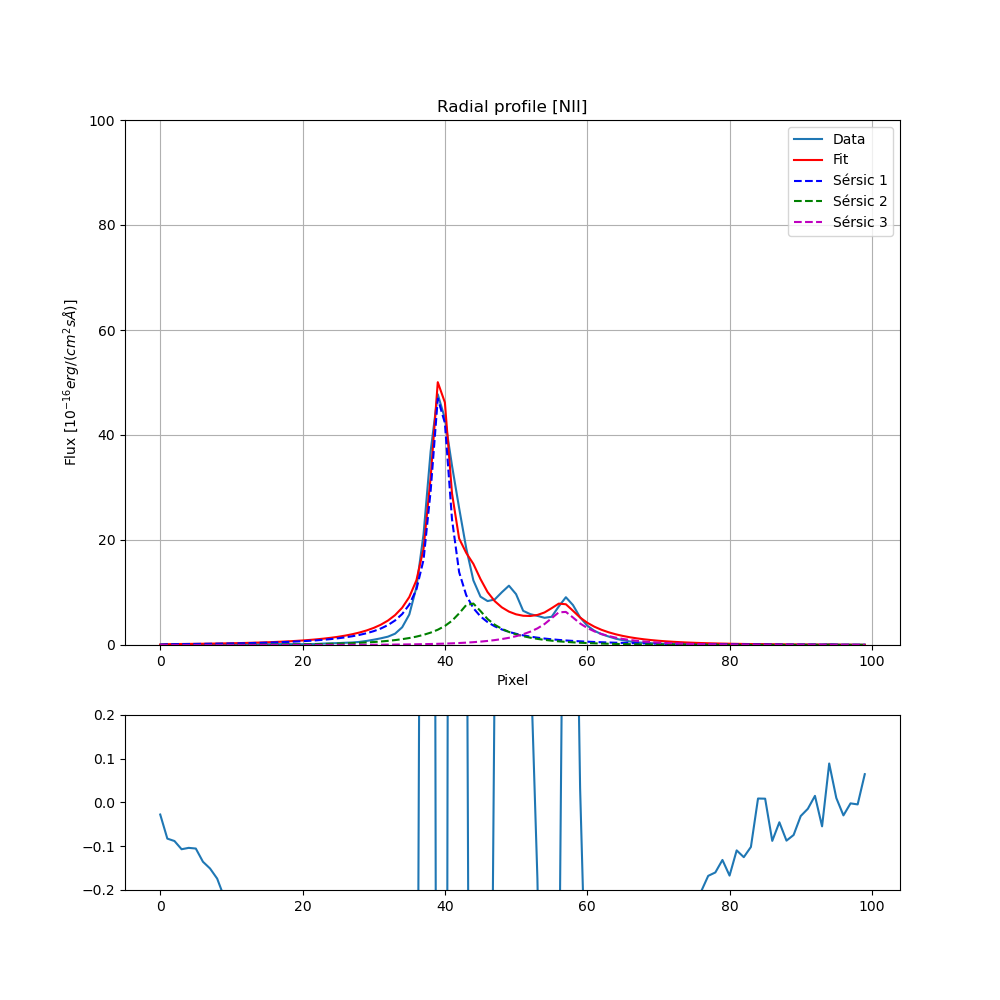

In [24]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_NII, r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [25]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(model_convolved, x_axes, radial_profile_NII, p0=result.x, sigma = radial_profile_error_NII, bounds = bounds_list, maxfev=10000)

chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, radial_profile_error_NII,
    x_axes, n_component, line_name="NII", output_prefix="fit")

Sérsic 1: I_e=1.0000, r_e=10.8224, n=3.1957, x_0=39.2765
Sérsic 2: I_e=1.0000, r_e=10.5352, n=1.5564, x_0=43.6216
Sérsic 3: I_e=1.0000, r_e=8.5319, n=1.2747, x_0=56.4204
[ 3.80793115 31.78639327  2.95140074  0.09119068  2.53993254 29.78113722
  1.72843625  0.58829471  0.66115154  4.9688666   0.47941769  0.48158661]
615.3642585947265


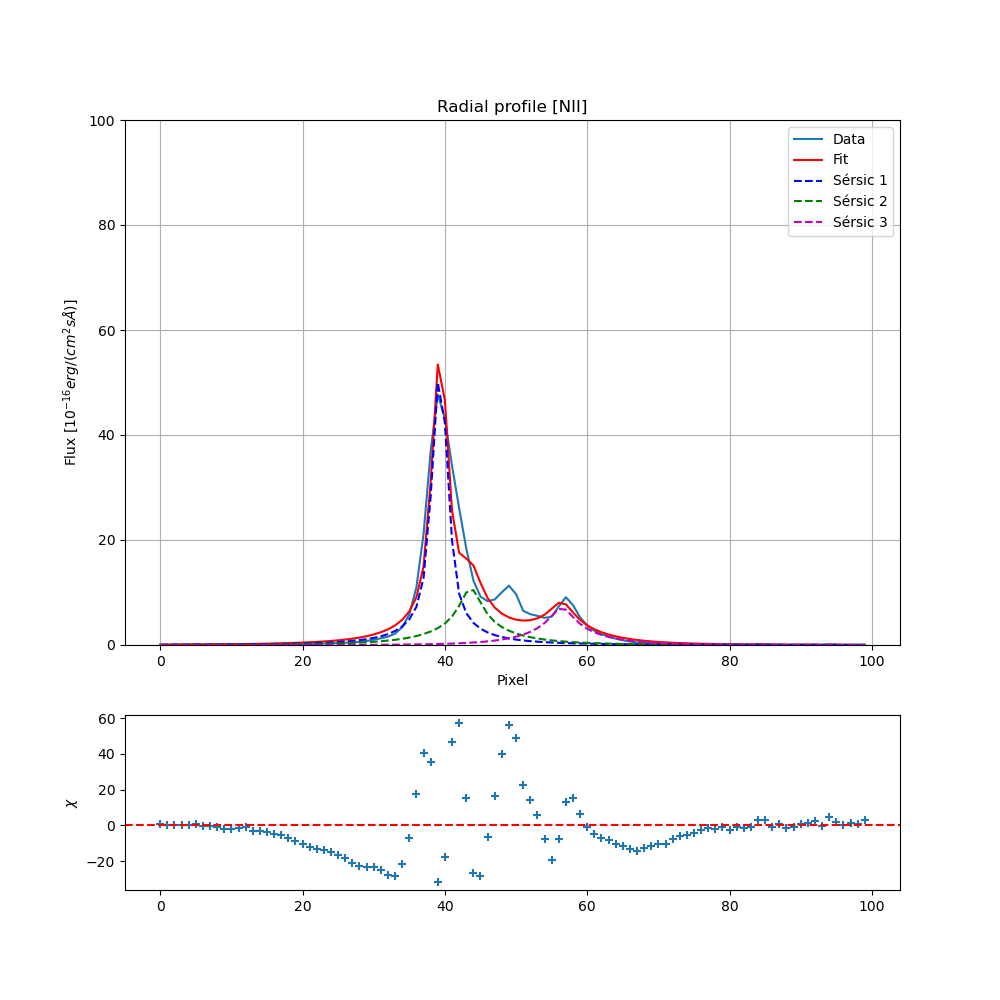

In [26]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

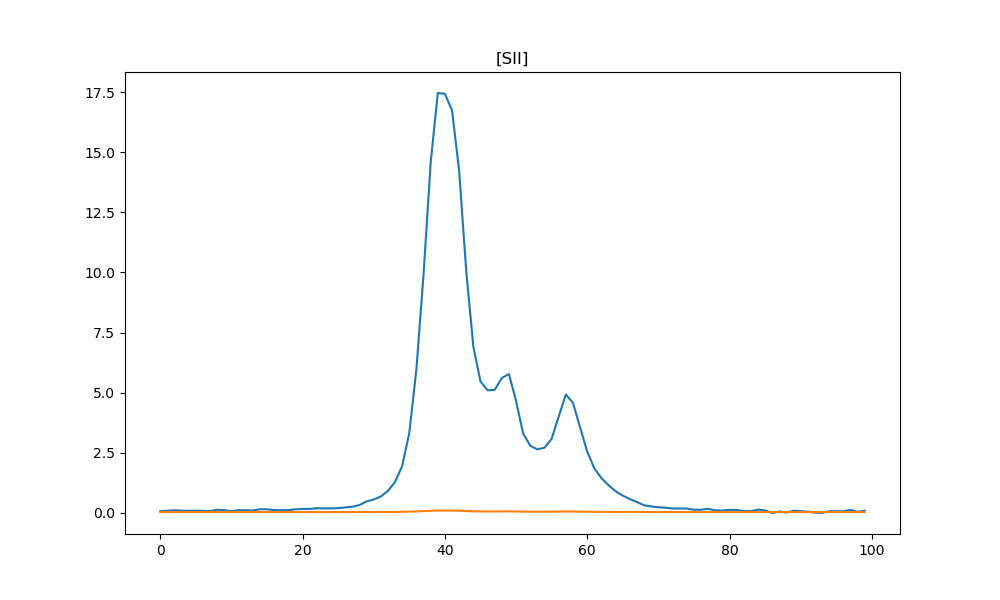

In [27]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [28]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 295.95217292298156
differential_evolution step 2: f(x)= 232.17968527150748
differential_evolution step 3: f(x)= 190.67144017185328
differential_evolution step 4: f(x)= 121.0686284655212
differential_evolution step 5: f(x)= 121.0686284655212
differential_evolution step 6: f(x)= 121.0686284655212
differential_evolution step 7: f(x)= 121.0686284655212
differential_evolution step 8: f(x)= 121.0686284655212
differential_evolution step 9: f(x)= 121.0686284655212
differential_evolution step 10: f(x)= 121.0686284655212
differential_evolution step 11: f(x)= 121.0686284655212
differential_evolution step 12: f(x)= 95.52875393510612
differential_evolution step 13: f(x)= 95.52875393510612
differential_evolution step 14: f(x)= 95.52875393510612
differential_evolution step 15: f(x)= 95.52875393510612
differential_evolution step 16: f(x)= 95.52875393510612
differential_evolution step 17: f(x)= 95.52875393510612
differential_evolution step 18: f(x)= 95.5287539351061

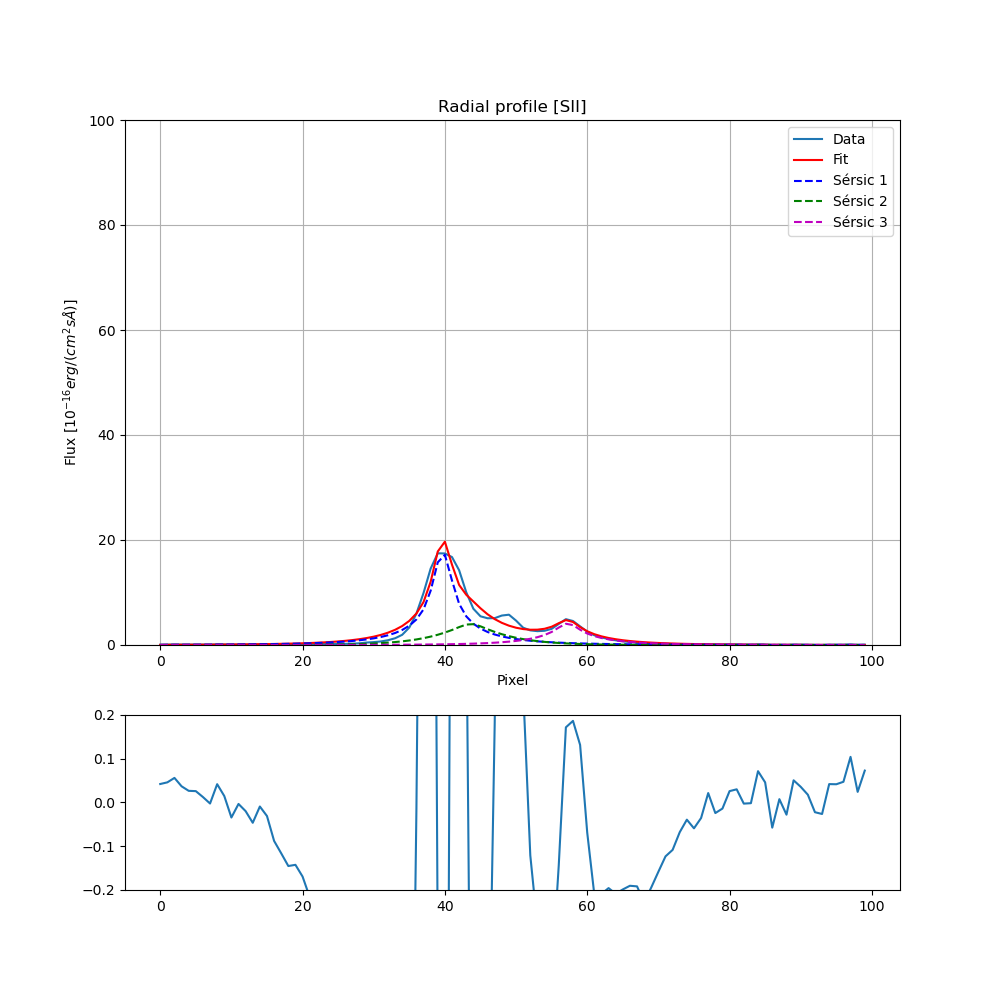

In [29]:
plot_diff(x_axes, best_params, radial_profile_SII, r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [30]:
params_curve_SII, covariance_SII = curve_fit(model_convolved, x_axes, radial_profile_SII, p0=result.x, sigma = radial_profile_error_SII)

chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, radial_profile_error_SII,
    x_axes, n_component, line_name="SII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16936\3403565850.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16936\3403565850.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16936\3403565850.py:9: RuntimeWarning: overflow encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Sérsic 1: I_e=4.3144, r_e=3.8389, n=0.8830, x_0=39.7420
Sérsic 2: I_e=2.7890, r_e=7.0502, n=0.0753, x_0=43.9352
Sérsic 3: I_e=0.6566, r_e=8.7613, n=1.3245, x_0=57.0582
[0.43957255 0.19290805 0.07727201 0.09046209 1.10102844 1.09993474
 0.04324311 0.22675969 0.13824419 1.27617632 0.15179468 0.1202106 ]
38.00551742861427


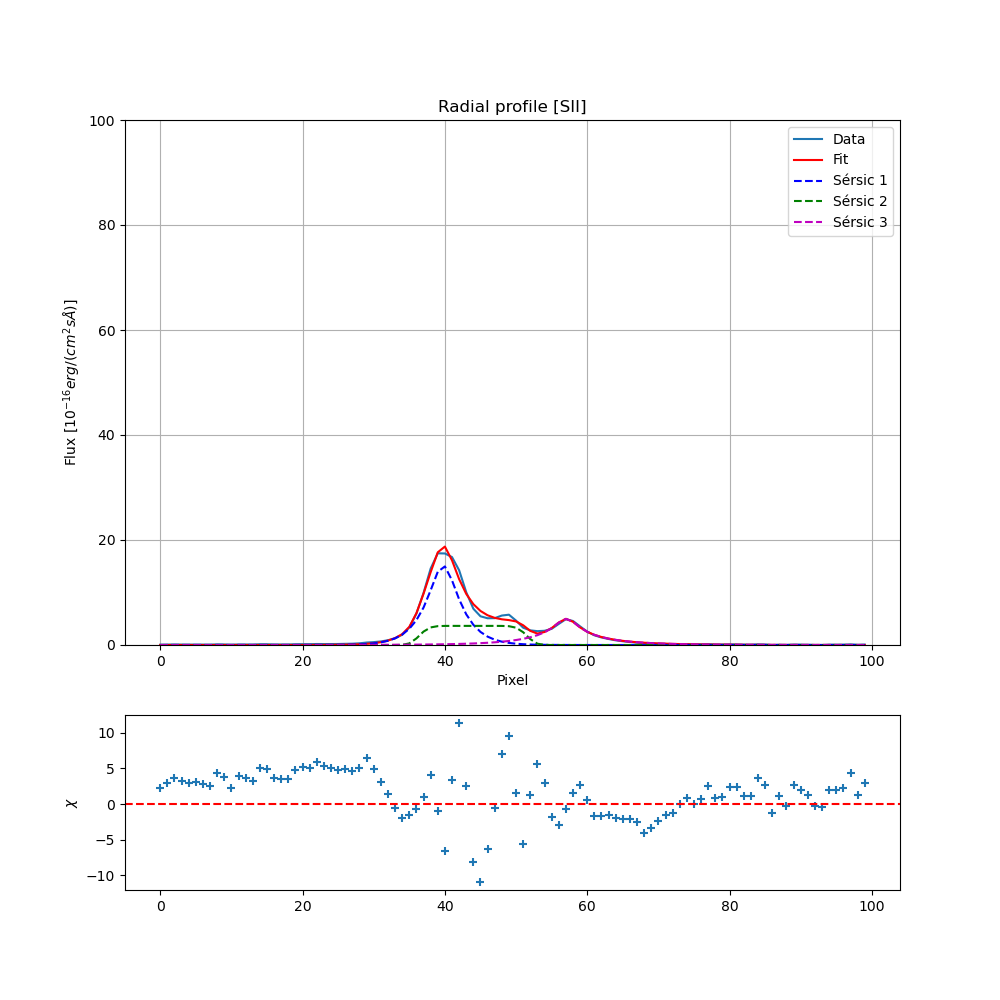

In [31]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

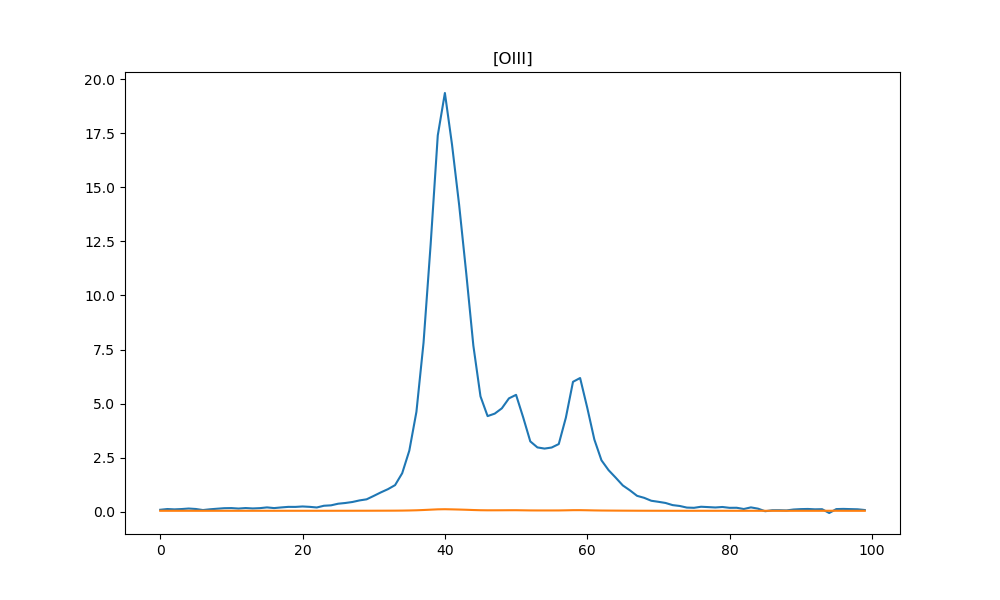

In [32]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [33]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 365.155112190279
differential_evolution step 2: f(x)= 253.71397944767276
differential_evolution step 3: f(x)= 253.34144908069078
differential_evolution step 4: f(x)= 149.08936236385335
differential_evolution step 5: f(x)= 149.08936236385335
differential_evolution step 6: f(x)= 135.1141815495146
differential_evolution step 7: f(x)= 135.1141815495146
differential_evolution step 8: f(x)= 115.71373347581977
differential_evolution step 9: f(x)= 103.05393750806196
differential_evolution step 10: f(x)= 103.05393750806196
differential_evolution step 11: f(x)= 103.05393750806196
differential_evolution step 12: f(x)= 100.23780572367497
differential_evolution step 13: f(x)= 95.64457850058557
differential_evolution step 14: f(x)= 95.64457850058557
differential_evolution step 15: f(x)= 95.64457850058557
differential_evolution step 16: f(x)= 95.64457850058557
differential_evolution step 17: f(x)= 95.64457850058557
differential_evolution step 18: f(x)= 95.64457850

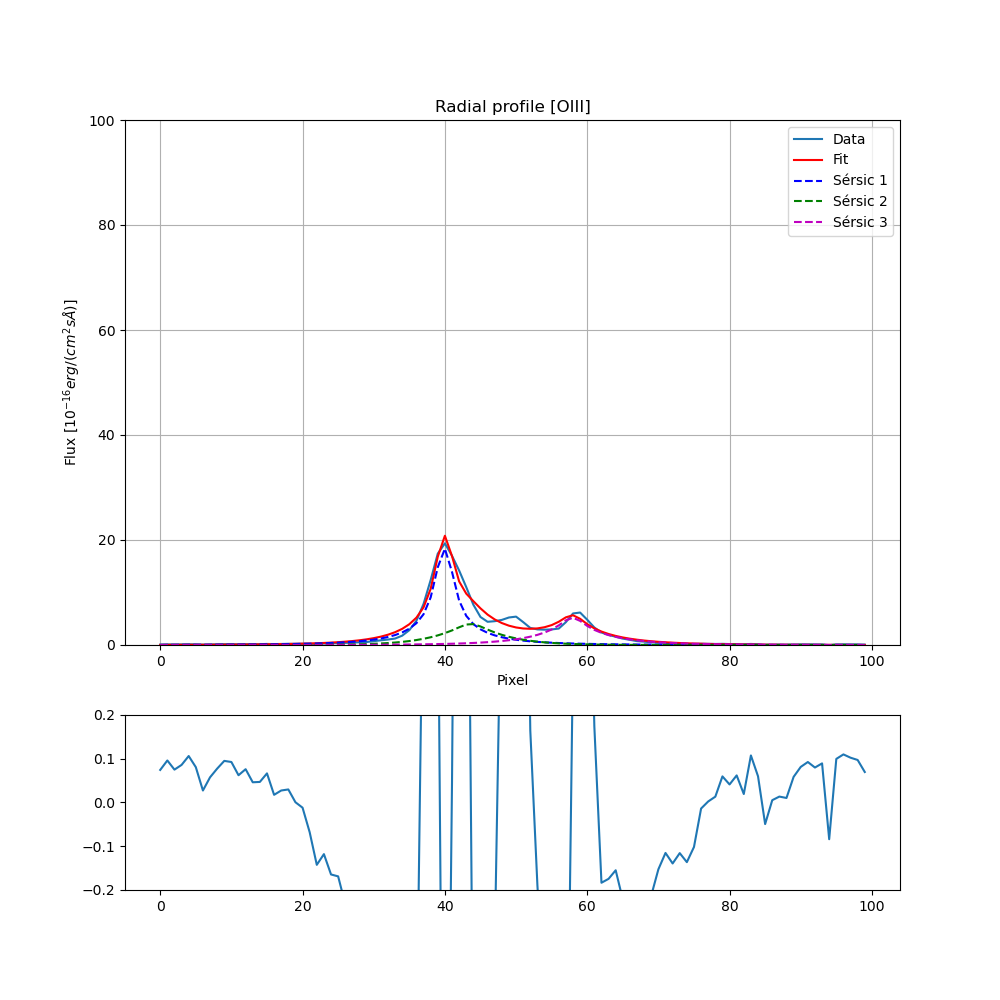

In [34]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_OIII, r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [35]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(model_convolved, x_axes, radial_profile_OIII, p0=result.x, sigma = radial_profile_error_OIII, bounds = bounds_list, maxfev=10000)


chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, radial_profile_error_OIII,
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Sérsic 1: I_e=1.0000, r_e=8.3642, n=2.1373, x_0=39.8946
Sérsic 2: I_e=1.0000, r_e=7.9345, n=0.9779, x_0=43.6216
Sérsic 3: I_e=0.7344, r_e=9.9582, n=1.2442, x_0=57.9312
[1.28556712 8.38703483 0.89901663 0.11926872 1.16687222 8.34473353
 0.70534514 1.37745489 0.37069868 3.06987024 0.32191771 0.31448596]
91.86343793477704


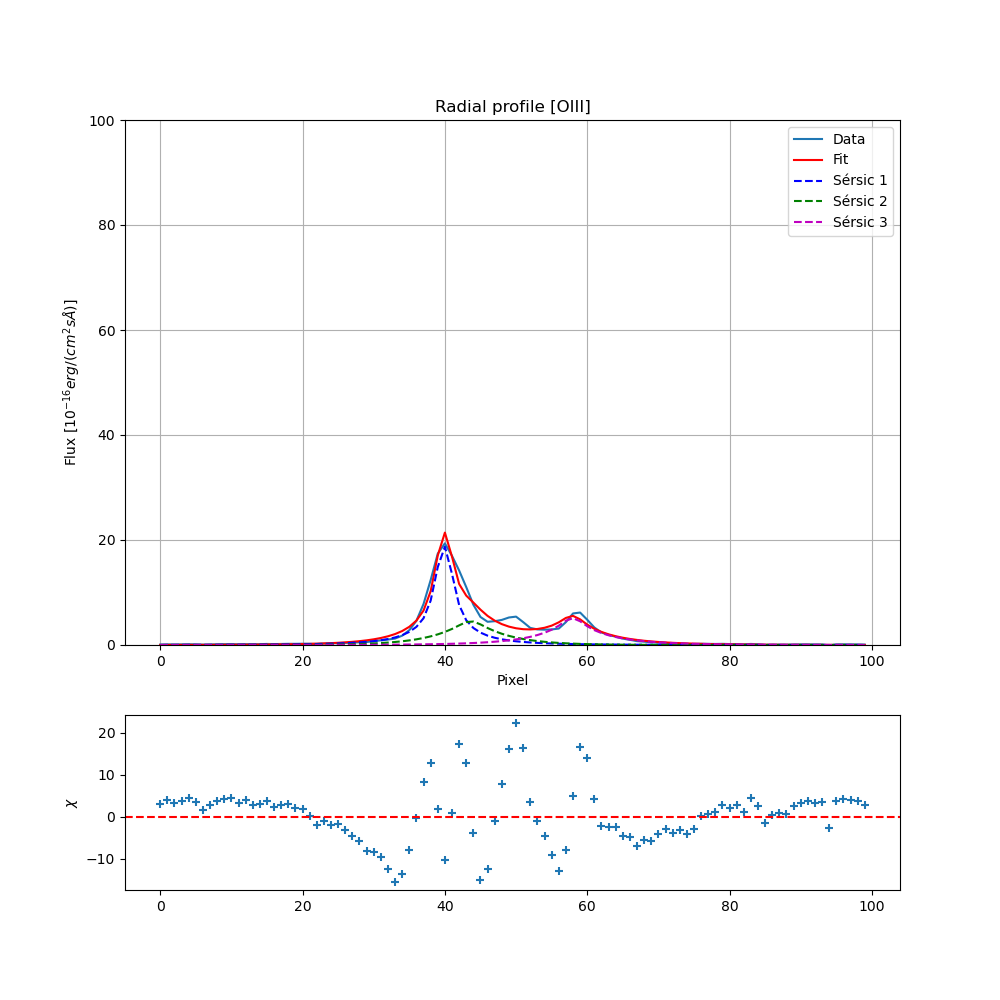

In [36]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [37]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

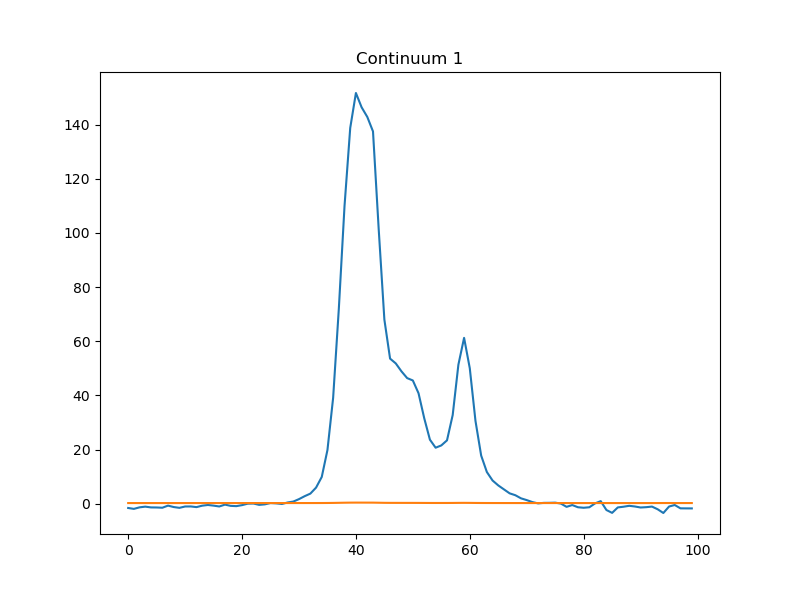

In [38]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [39]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 44763.41031408579
differential_evolution step 2: f(x)= 44763.41031408579
differential_evolution step 3: f(x)= 32295.560155717783
differential_evolution step 4: f(x)= 32295.560155717783
differential_evolution step 5: f(x)= 28986.764643131897
differential_evolution step 6: f(x)= 28986.764643131897
differential_evolution step 7: f(x)= 28986.764643131897
differential_evolution step 8: f(x)= 25735.939051404235
differential_evolution step 9: f(x)= 25735.939051404235
differential_evolution step 10: f(x)= 25735.939051404235
differential_evolution step 11: f(x)= 25735.939051404235
differential_evolution step 12: f(x)= 21434.258888966782
differential_evolution step 13: f(x)= 21434.258888966782
differential_evolution step 14: f(x)= 21434.258888966782
differential_evolution step 15: f(x)= 21434.258888966782
differential_evolution step 16: f(x)= 21434.258888966782
differential_evolution step 17: f(x)= 17740.149075477057
differential_evolution step 18: f(x)= 1774

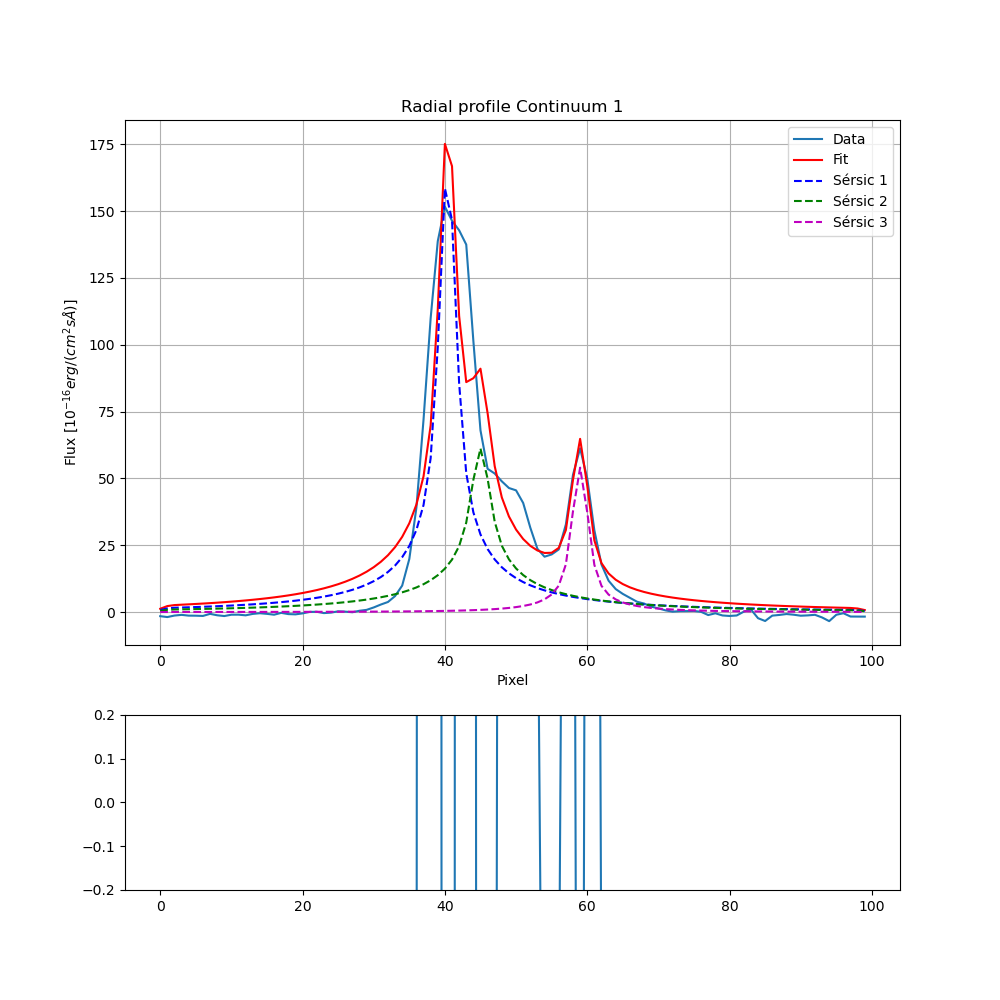

In [40]:
def plot_curve(x_axes, params_curve, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 1450)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 1450)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)
    
plot_diff(x_axes, best_params, radial_profile_continuum_1, r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [42]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_1, covariance_continuum_1 = curve_fit(model_convolved, x_axes, radial_profile_continuum_1, p0=result.x, sigma = radial_profile_error_continuum_1, bounds = bounds_list, maxfev=15000)

chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, radial_profile_continuum_1, radial_profile_error_continuum_1,
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

RuntimeError: Optimal parameters not found: The maximum number of function evaluations is exceeded.

In [ ]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

In [ ]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [ ]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
def plot_curve(x_axes, params_curve, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, )
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, )
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)
plot_diff(x_axes, best_params, radial_profile_continuum_2, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [ ]:
params_curve_continuum_2, covariance_continuum_2 = curve_fit(model_convolved, x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = radial_profile_error_continuum_2)#, maxfev=15000)
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
    radial_profile_error_continuum_2, x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

In [ ]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

In [ ]:
mask_continuum_3 = (wv > 6400)*(wv < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [ ]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
def plot_curve(x_axes, params_curve, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 20)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 20)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)
    
plot_diff(x_axes, best_params, radial_profile_continuum_3, r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [ ]:
params_curve_continuum_3, covariance_continuum_3 = curve_fit(model_convolved, x_axes, radial_profile_continuum_3, p0=result.x, sigma = radial_profile_error_continuum_3)

chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
    radial_profile_error_continuum_3, x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

In [ ]:
plot_diff(x_axes, params_curve_continuum_3, radial_profile_continuum_3, r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [ ]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII, 
           chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII, 
           dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII, 
           chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII', 'Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

In [ ]:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 20),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (70, 80),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (90, 100)
]

lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
